# Run Configured M3Resp Workflow

This notebook runs the M3Resp workflow selected by `examples/config.yaml`: EIT-only, EMG-only, or combined EIT+EMG.

The YAML `modules` flags control which workflow is selected. When both EIT and EMG are enabled, the configured workflow also performs EMG postprocessing and temporal alignment.

It mirrors the production script `examples/workflow.py` step-by-step so every cell can be executed independently or re-run in sequence.


## Setup

Bootstrap the local source checkout, then use the workflow toolbox for package and sibling-repository paths.


In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path


def _find_repo_root(start: Path | None = None) -> Path:
    """Find the local m3resp repository root before m3resp is importable."""
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (
            Path(os.path.join(str(candidate), "pyproject.toml")).exists()
            and Path(os.path.join(str(candidate), "src", "m3resp")).exists()
        ):
            return candidate
    raise RuntimeError(
        "Could not find the m3resp repository root. "
        "Start Jupyter from the repo or notebooks folder."
    )


_repo_root = _find_repo_root()
_src_path = Path(os.path.join(str(_repo_root), "src"))
if _src_path.exists() and str(_src_path) not in sys.path:
    sys.path.insert(0, str(_src_path))

from m3resp.workflows.toolbox import (  # noqa: E402
    configure_workflow_logging,
    configure_workflow_paths,
    log_workflow_summary,
)

REPO_ROOT = configure_workflow_paths("eitprocessing")
REPO_ROOT


PosixPath('/home/mahyart/Desktop/github_repos/m3resp-org/m3resp')

In [2]:
from m3resp import load_workflow_config
from m3resp.workflows import run_workflow

## Configuration

The notebook uses the same YAML file as the runnable example scripts.


In [3]:
CONFIG_PATH = REPO_ROOT / "examples" / "config.yaml"
cfg = load_workflow_config(CONFIG_PATH)
cfg

WorkflowConfig(modules=ModuleFlags(eit=True, emg=True, vent=True), eit=EITWorkflowConfig(file=PosixPath('/home/mahyart/Desktop/github_repos/m3resp-org/m3resp/data/source/draeger_synthetic_draeger_20Hz.bin'), vendor='draeger', processing=EITProcessingConfig(preprocess=SwitchConfig(enabled=True), filter=EITFilterConfig(enabled=True, mode='mdn', lowpass_hz=1.0, highpass_hz=0.05, order=4), breath_detection=SwitchConfig(enabled=True), results=EITResultsConfig(rates=True, breath_intervals=True, continuous_tiv=True, eeli=True, pixel_tiv=True, filtered_data=True, global_impedance=True), subject_type='adult', welch_window_seconds=30.0, breath_min_duration_seconds=0.6666666667)), emg=EMGWorkflowConfig(file=PosixPath('/home/mahyart/Desktop/github_repos/m3resp-org/m3resp/data/source/emg_data_synth_quiet_breathing.Poly5'), processing=EMGProcessingConfig(preprocess=EMGPreprocessConfig(enabled=True, channel=0, high_pass_hz=80, low_pass_hz=None, envelope_window_seconds=0.5), breath_detection=EMGDetect

## Run Workflow

Run the package-level configured workflow. The returned result contains the populated session, summary values, export directory, and saved figure paths.


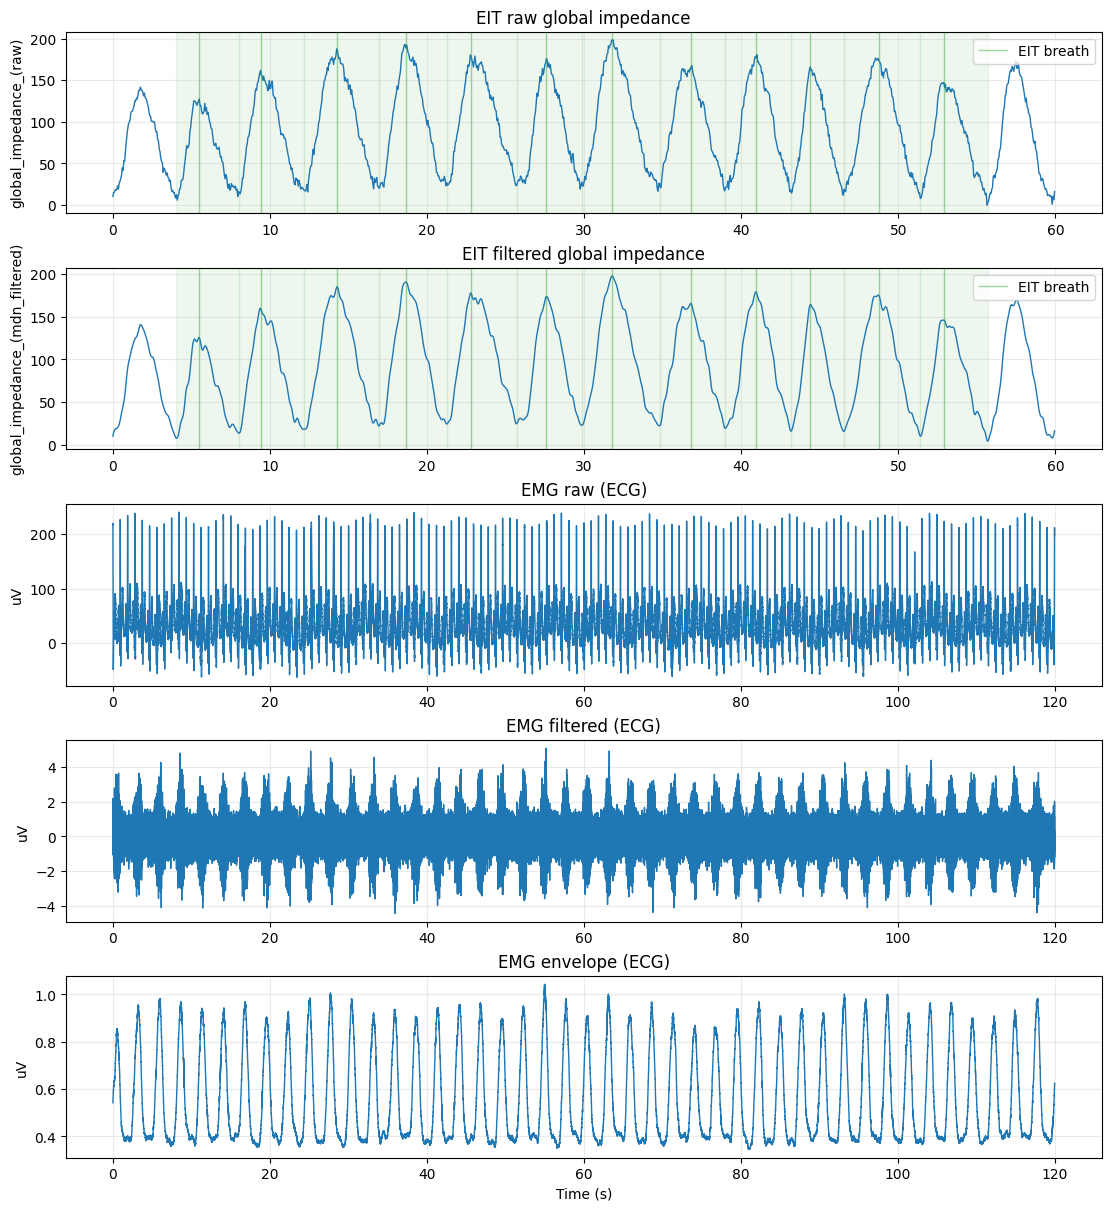

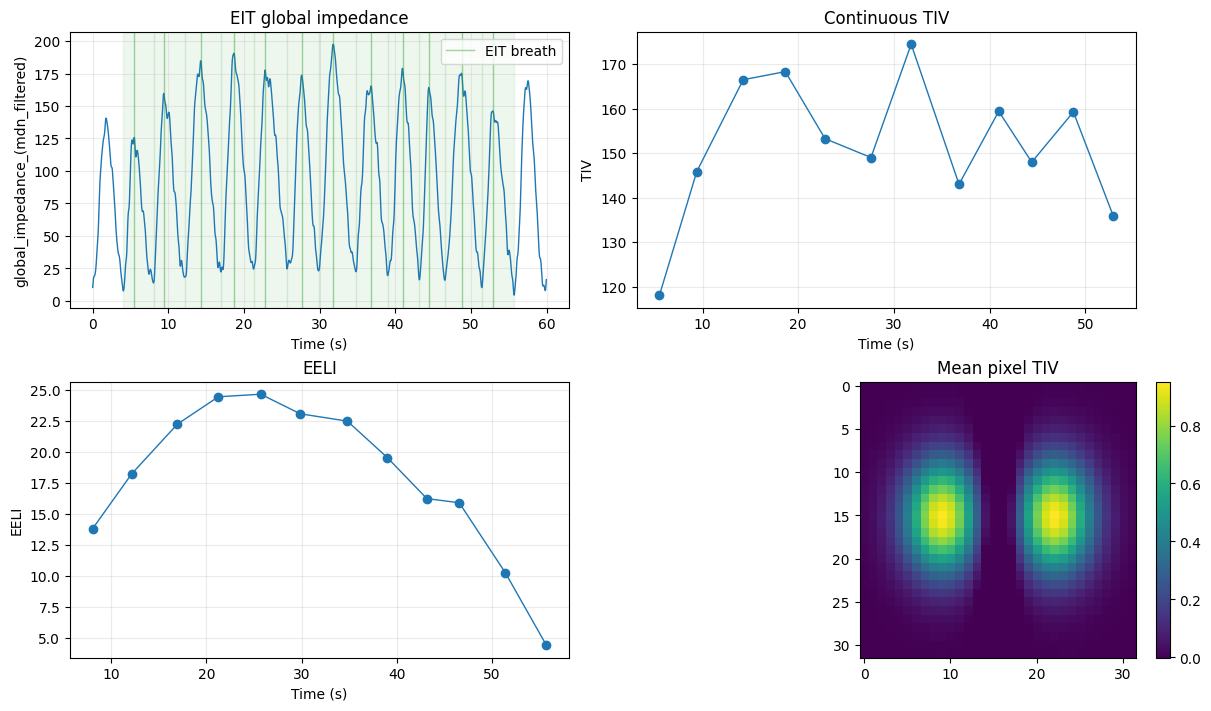

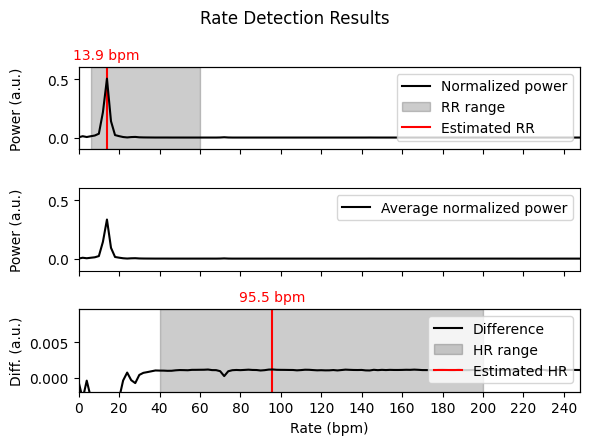

In [4]:
result = run_workflow(config=cfg)
session = result.session

## Processing Summary

Log the same compact summary as `examples/workflow.py`.


In [5]:
configure_workflow_logging()
log_workflow_summary(
    "Configured workflow complete.",
    result.output_dir,
    result.summary,
    active_modules={
        "eit": cfg.modules.eit,
        "emg": cfg.modules.emg,
        "vent": cfg.modules.vent,
    },
)


02:15:01 | SUCCESS  | Configured workflow complete.
02:15:01 | INFO     | Output directory: /home/mahyart/Desktop/github_repos/m3resp-org/m3resp/output/multimodal-summary
02:15:01 | INFO     | Active modules: eit=on, emg=on, vent=on
02:15:01 | INFO     | filter_mode: mdn
02:15:01 | INFO     | respiratory_rate_bpm: 13.88224396109581
02:15:01 | INFO     | heart_rate_bpm: 95.52607929706575
02:15:01 | INFO     | n_eit_breaths: 12
02:15:01 | INFO     | n_continuous_tiv_values: 12
02:15:01 | INFO     | n_eeli_values: 12
02:15:01 | INFO     | pixel_tiv_shape_per_breath: (32, 32)
02:15:01 | INFO     | n_emg_breaths: 0
02:15:01 | INFO     | n_ventilator_breaths: 154
02:15:01 | INFO     | EMG postprocessing available: baseline (2), event detection (5), features (6), quality assessment (10)
02:15:01 | INFO     | EMG postprocessing computed:
02:15:01 | INFO     |   baseline: moving_baseline, slopesum_baseline
02:15:01 | INFO     |   event detection: detect_ventilator_breath, find_occluded_breaths


## Visualize Output

Configured workflows save available figures into the configured output directory.


/home/mahyart/Desktop/github_repos/m3resp-org/m3resp/output/multimodal-summary/overview.png


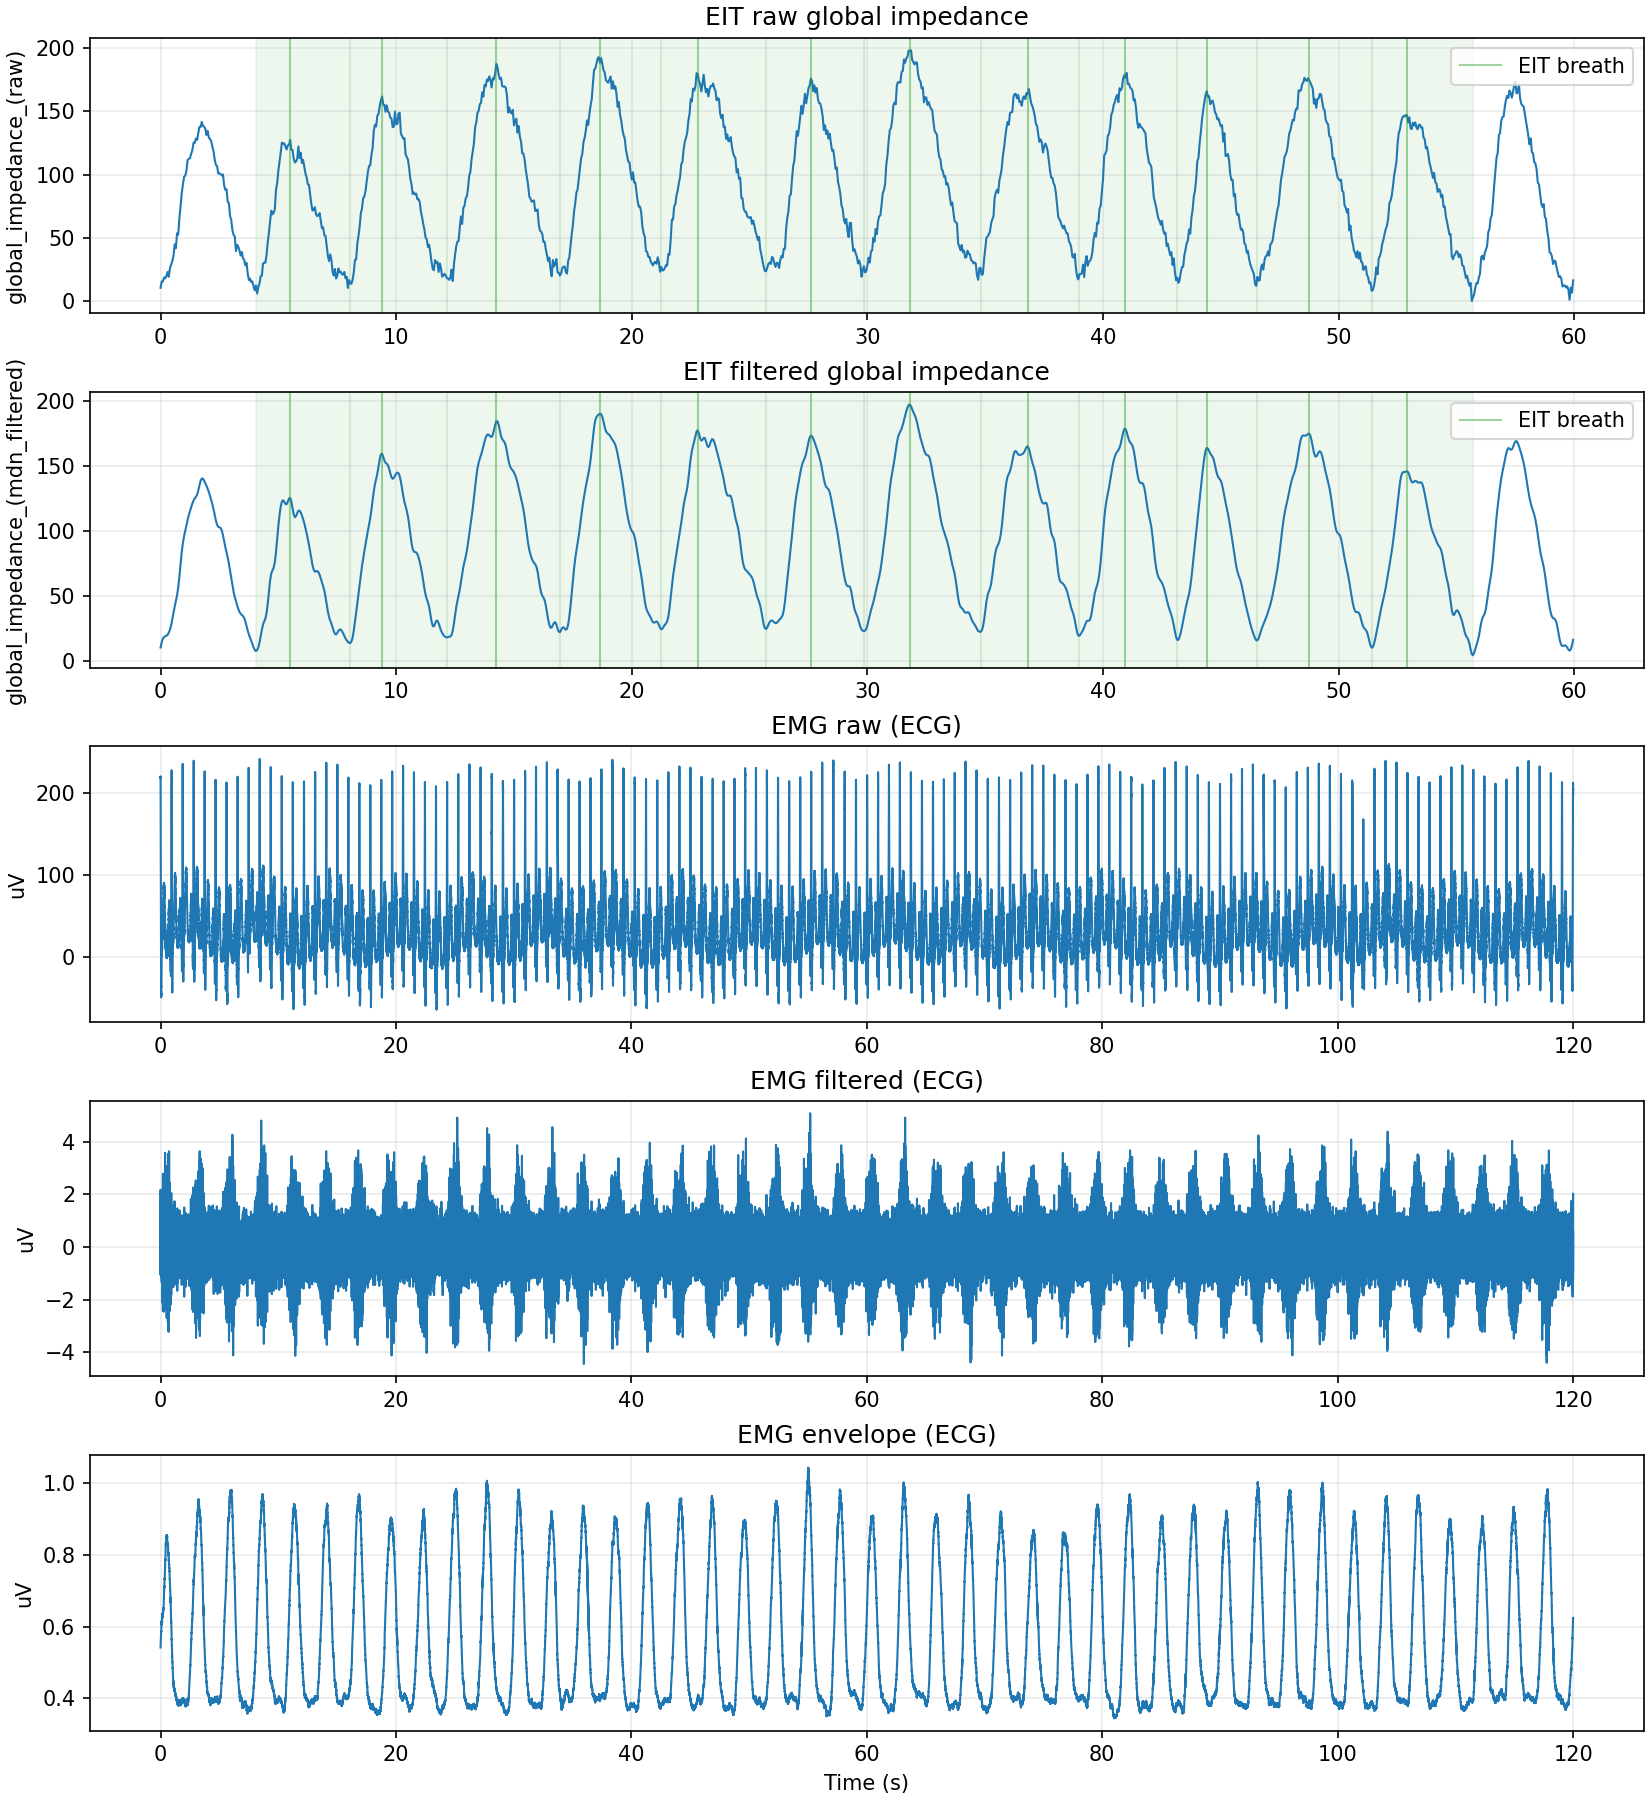

/home/mahyart/Desktop/github_repos/m3resp-org/m3resp/output/multimodal-summary/eit-processing.png


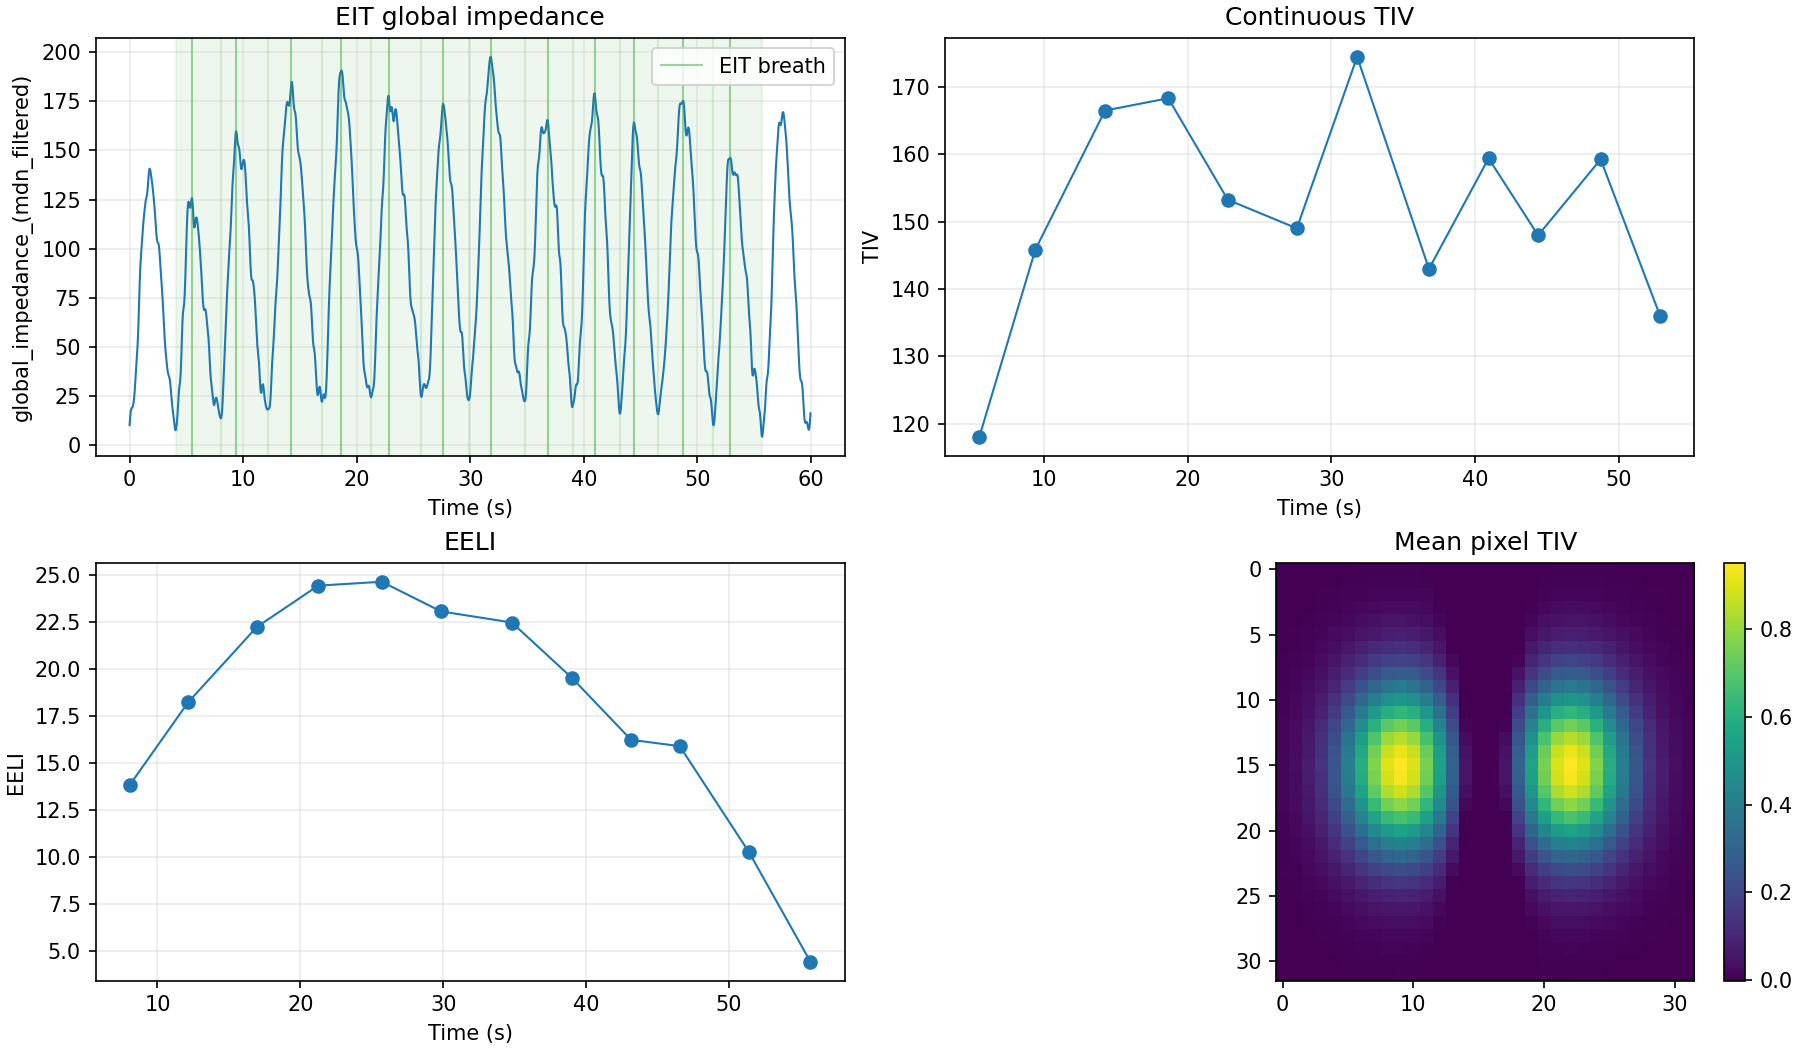

/home/mahyart/Desktop/github_repos/m3resp-org/m3resp/output/multimodal-summary/eit-rate-detection.png


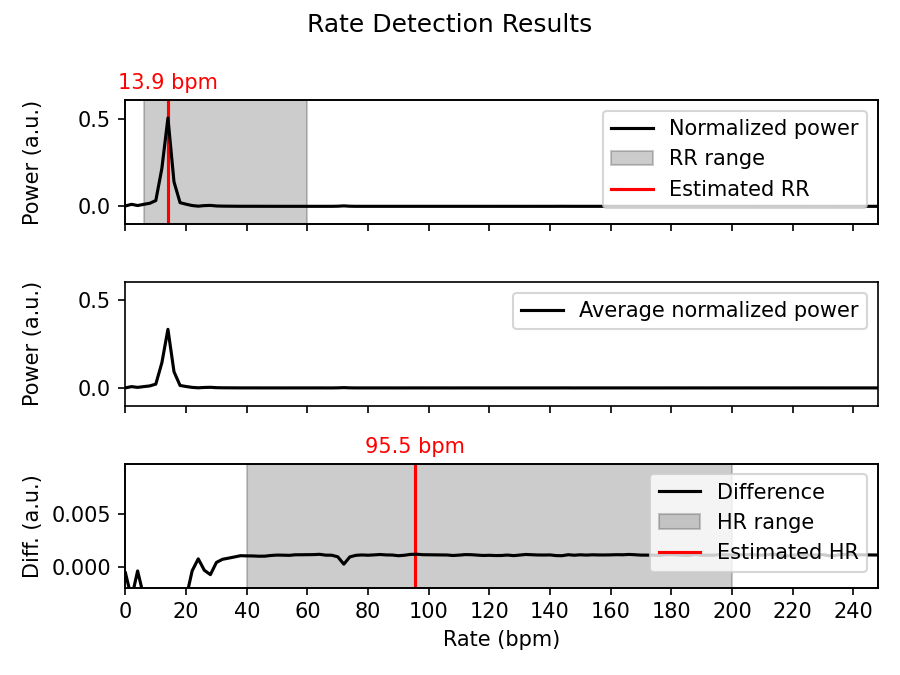

In [6]:
from IPython.display import Image, display

for figure_path in result.figures.values():
    print(figure_path)
    display(Image(filename=str(figure_path)))